In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/multimodal_emotion_ Recognisation/TESS Toronto emotional speech set data"

print(os.listdir(dataset_path)[:5])

['OAF_angry', 'OAF_disgust', 'OAF_Fear', 'OAF_happy', 'OAF_neutral']


In [3]:
!pip install tensorflow scikit-learn librosa seaborn

In [4]:
# IMPORT LIBRARIES


import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Concatenate

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [5]:

# LOAD MULTIMODAL DATA

speech_features = []
text_inputs = []
emotion_labels = []

print("Loading multimodal dataset...")

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            try:

                file_path = os.path.join(root, file)

                filename = file.replace(".wav", "")

                # SPLIT FILENAME

                parts = filename.split("_")

                word = parts[1].lower().strip()

                emotion = parts[-1].lower().strip()

                # label normalization
                emotion = emotion.split(" ")[0]


                audio, sr = librosa.load(
                    file_path,
                    sr=22050,
                    mono=True
                )

                # MFCC FEATURE EXTRACTION


                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                mfcc = np.mean(mfcc.T, axis=0)


                speech_features.append(mfcc)
                text_inputs.append(word)
                emotion_labels.append(emotion)

            except Exception as e:

                print(f"Error processing: {file}")
                print(e)

print("Multimodal dataset loaded successfully.")

print("\nTotal Samples:")
print(len(speech_features))

print("\nEmotion Classes:")
print(sorted(set(emotion_labels)))

Loading multimodal dataset...
Multimodal dataset loaded successfully.

Total Samples:
2802

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']


In [6]:

# TEXT TOKENIZATION

tokenizer = Tokenizer()

tokenizer.fit_on_texts(text_inputs)

text_sequences = tokenizer.texts_to_sequences(text_inputs)

text_features = pad_sequences(
    text_sequences,
    padding='post'
)

print("Text Feature Shape:", text_features.shape)

Text Feature Shape: (2802, 1)


In [7]:
# PREPARE SPEECH FEATURES


speech_features = np.array(speech_features)

speech_features = speech_features.reshape(
    speech_features.shape[0],
    speech_features.shape[1],
    1
)

print("Speech Feature Shape:", speech_features.shape)

Speech Feature Shape: (2802, 40, 1)


In [8]:
# LABEL ENCODING


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(emotion_labels)

y = to_categorical(y_encoded)

print("Emotion Classes:")
print(encoder.classes_)

Emotion Classes:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [9]:
# TRAIN TEST SPLIT

(
    speech_train,
    speech_test,
    text_train,
    text_test,
    y_train,
    y_test
) = train_test_split(
    speech_features,
    text_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", speech_train.shape[0])
print("Testing Samples:", speech_test.shape[0])

Training Samples: 2241
Testing Samples: 561


In [10]:

# BUILD MULTIMODAL FUSION MODEL


# SPEECH INPUT

speech_input = Input(shape=(40,1))

x1 = Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu'
)(speech_input)

x1 = MaxPooling1D(pool_size=2)(x1)

x1 = LSTM(64)(x1)


# TEXT INPUT


vocab_size = len(tokenizer.word_index) + 1

text_input = Input(shape=(text_features.shape[1],))

x2 = Embedding(
    input_dim=vocab_size,
    output_dim=32
)(text_input)

x2 = Flatten()(x2)

x2 = Dense(32, activation='relu')(x2)

# FUSION

fusion = Concatenate()([x1, x2])

fusion = Dense(64, activation='relu')(fusion)

fusion = Dropout(0.3)(fusion)

output = Dense(
    y.shape[1],
    activation='softmax'
)(fusion)


model = Model(
    inputs=[speech_input, text_input],
    outputs=output
)


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 38, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │      6,432 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 19, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,056 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7)         │        455 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 47,431 (185.28 KB)

 Trainable params: 47,431 (185.28 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:

# TRAIN FUSION MODEL


history = model.fit(
    [speech_train, text_train],
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(
        [speech_test, text_test],
        y_test
    )
)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5685 - loss: 1.2527 - val_accuracy: 0.8627 - val_loss: 0.4943
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8889 - loss: 0.3476 - val_accuracy: 0.9340 - val_loss: 0.1902
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9456 - loss: 0.1766 - val_accuracy: 0.9750 - val_loss: 0.0908
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9652 - loss: 0.1190 - val_accuracy: 0.9590 - val_loss: 0.1194
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9594 - loss: 0.1303 - val_accuracy: 0.9750 - val_loss: 0.0756
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9790 - loss: 0.0671 - val_accuracy: 0.9875 - val_loss: 0.0388
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9799 - loss: 0.0651 - val_accuracy: 0.9519 - val_loss: 0.1487
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9880 - loss: 0.0462 - val_accuracy: 0.9750 - v

In [12]:

# MODEL EVALUATION

loss, accuracy = model.evaluate(
    [speech_test, text_test],
    y_test
)

print("\nFusion Model Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9822 - loss: 0.0658

Fusion Model Accuracy: 0.9821746945381165


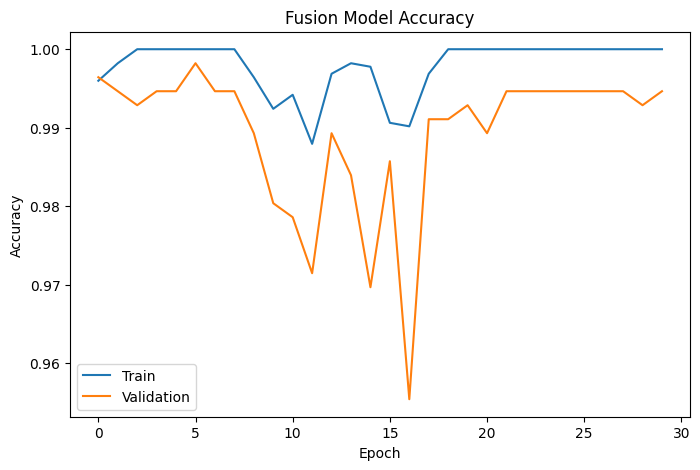

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


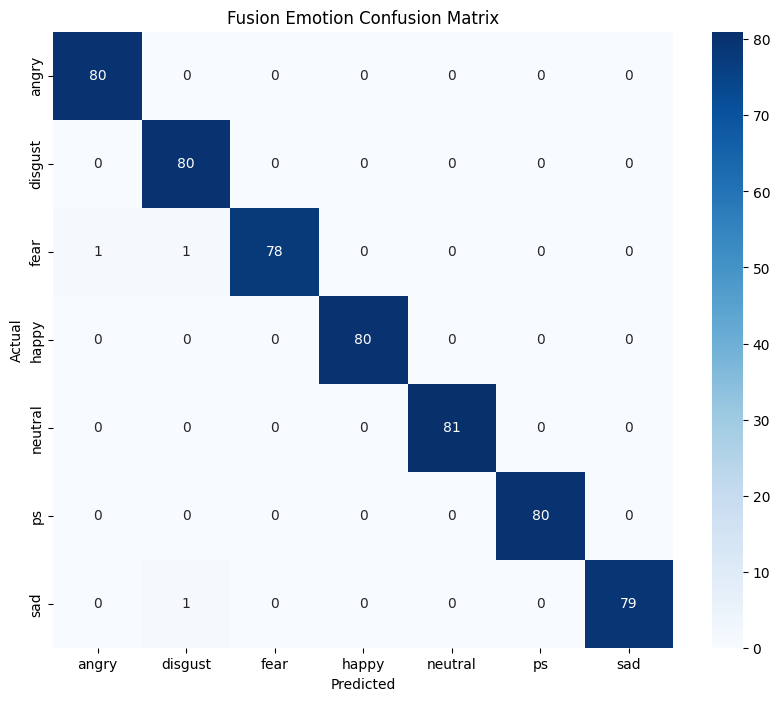

              precision    recall  f1-score   support

       angry       0.99      1.00      0.99        80
     disgust       0.98      1.00      0.99        80
        fear       1.00      0.97      0.99        80
       happy       1.00      1.00      1.00        80
     neutral       1.00      1.00      1.00        81
          ps       1.00      1.00      1.00        80
         sad       1.00      0.99      0.99        80

    accuracy                           0.99       561
   macro avg       0.99      0.99      0.99       561
weighted avg       0.99      0.99      0.99       561



In [14]:
# ACCURACY PLOT

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Fusion Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

# CONFUSION MATRIX

y_pred = model.predict(
    [speech_test, text_test]
)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Fusion Emotion Confusion Matrix")

plt.show()

# CLASSIFICATION REPORT

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=encoder.classes_,
        zero_division=0
    )
)

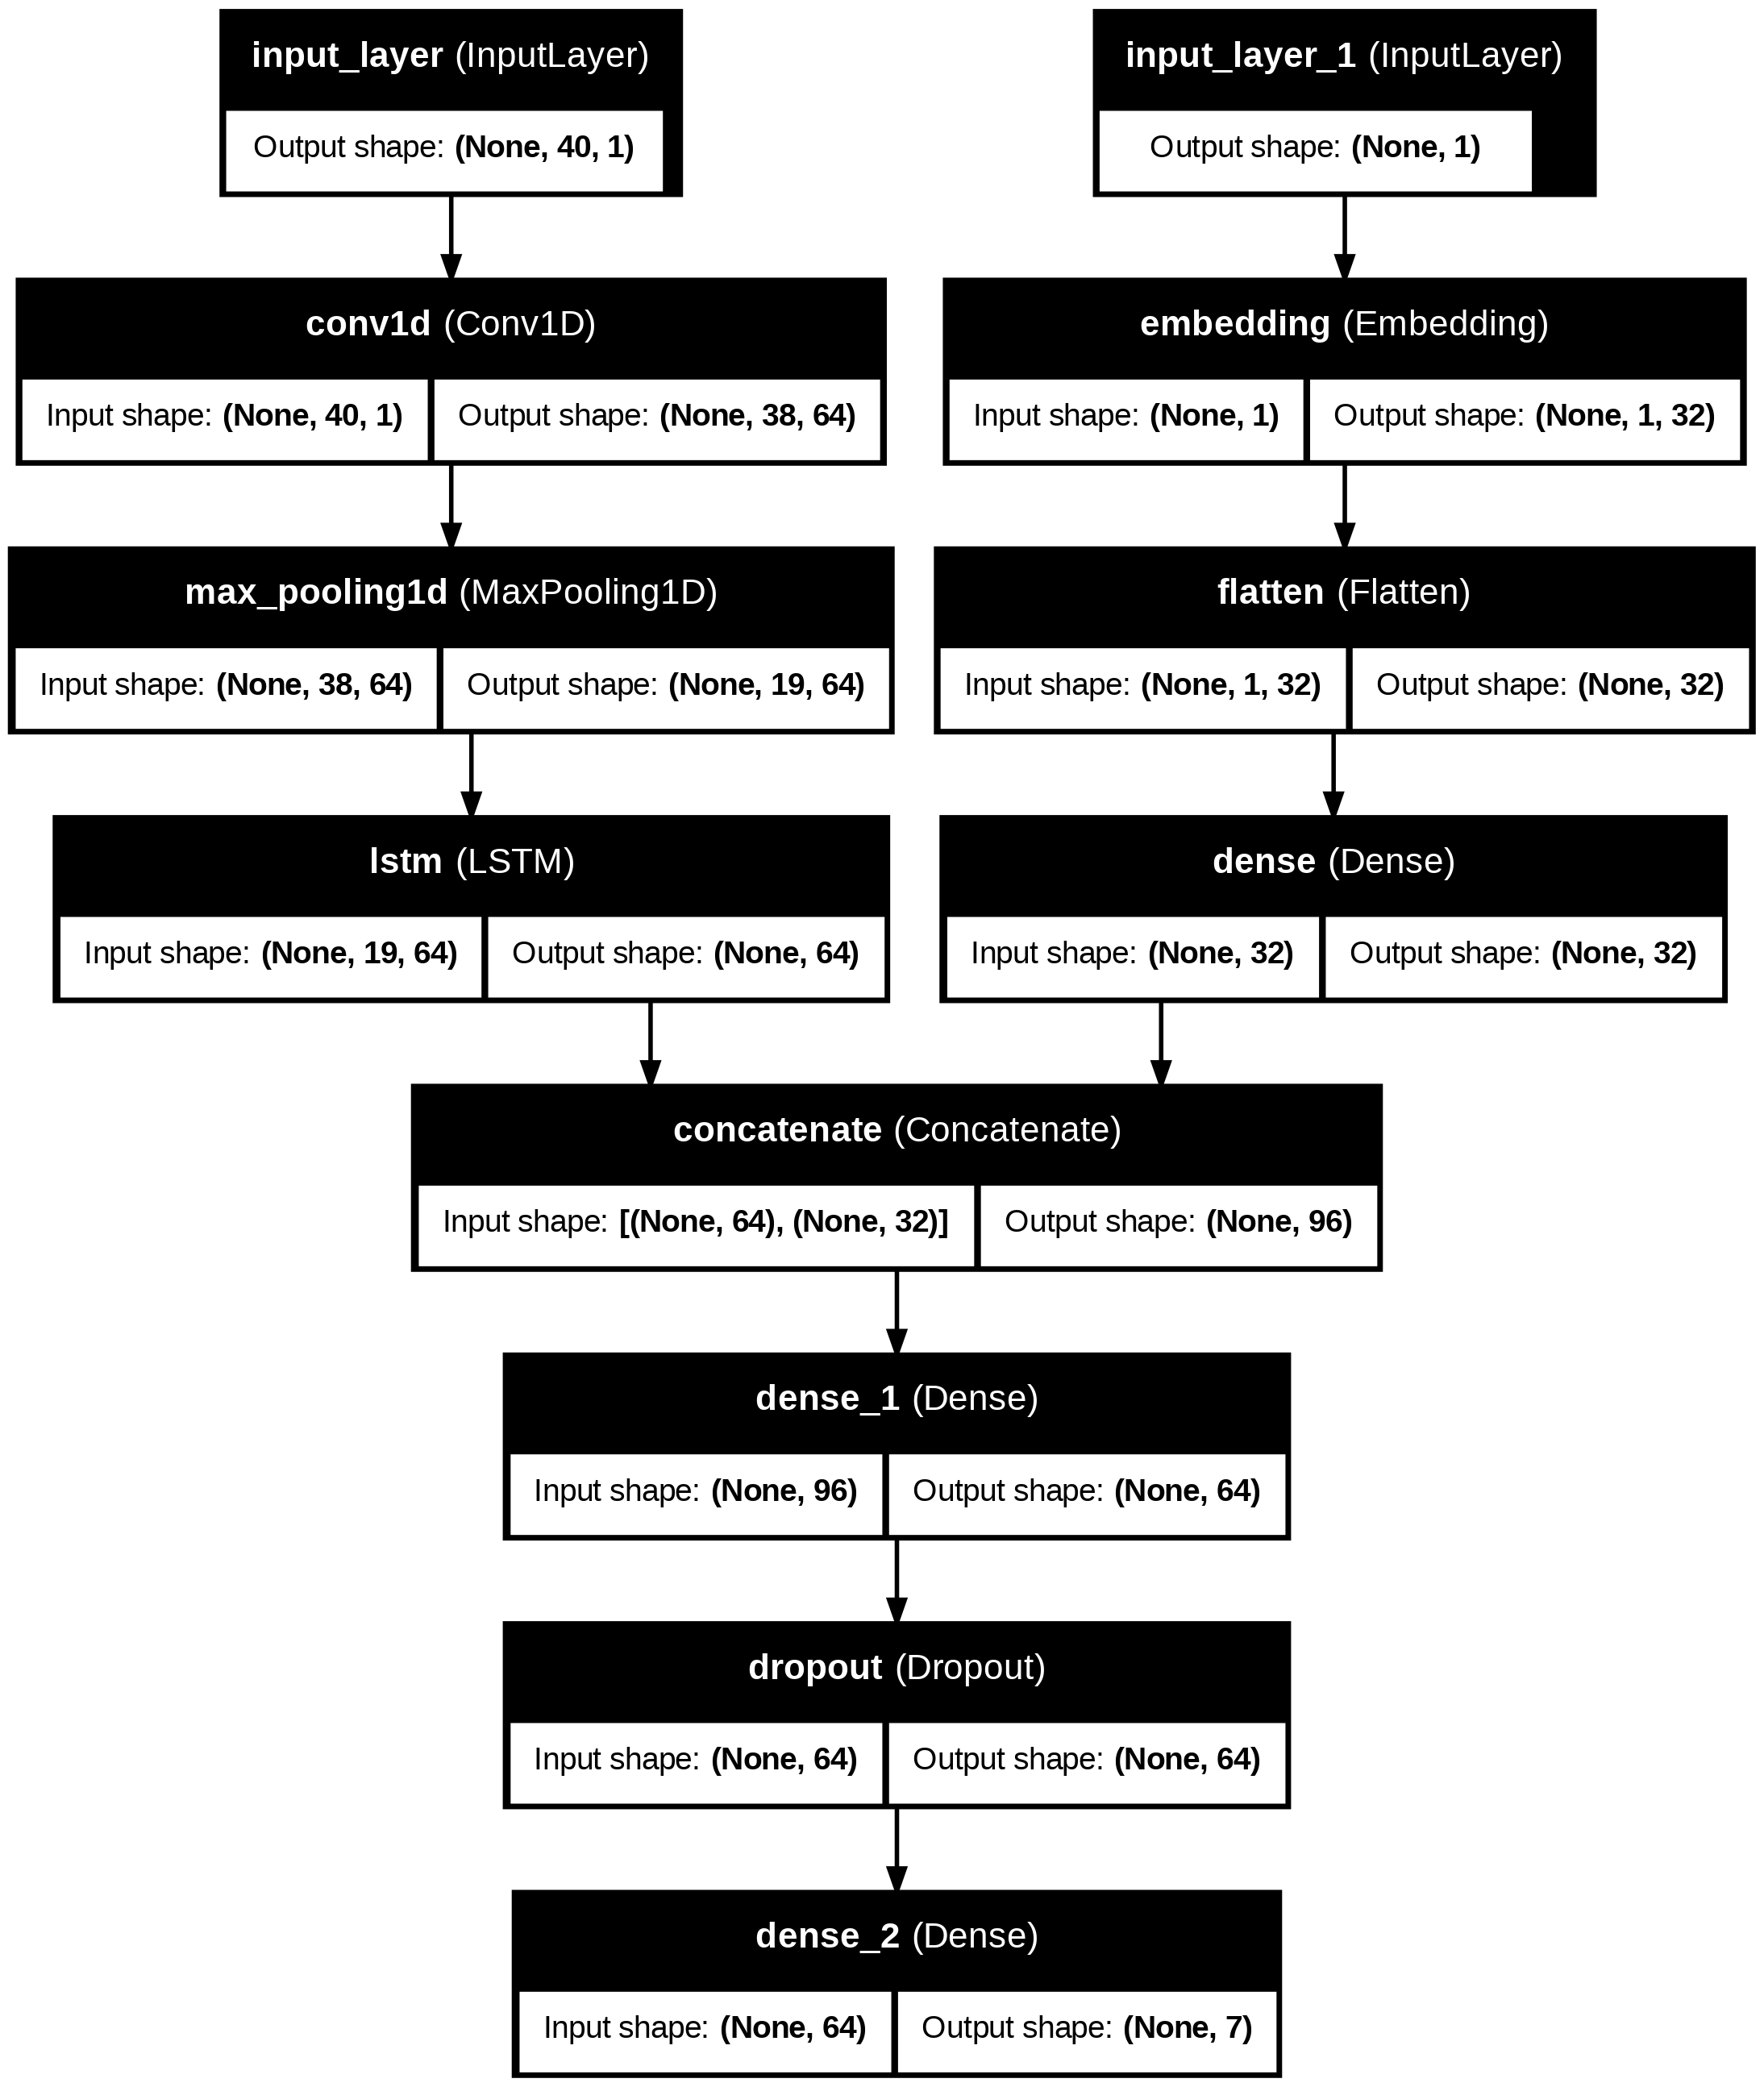

In [15]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


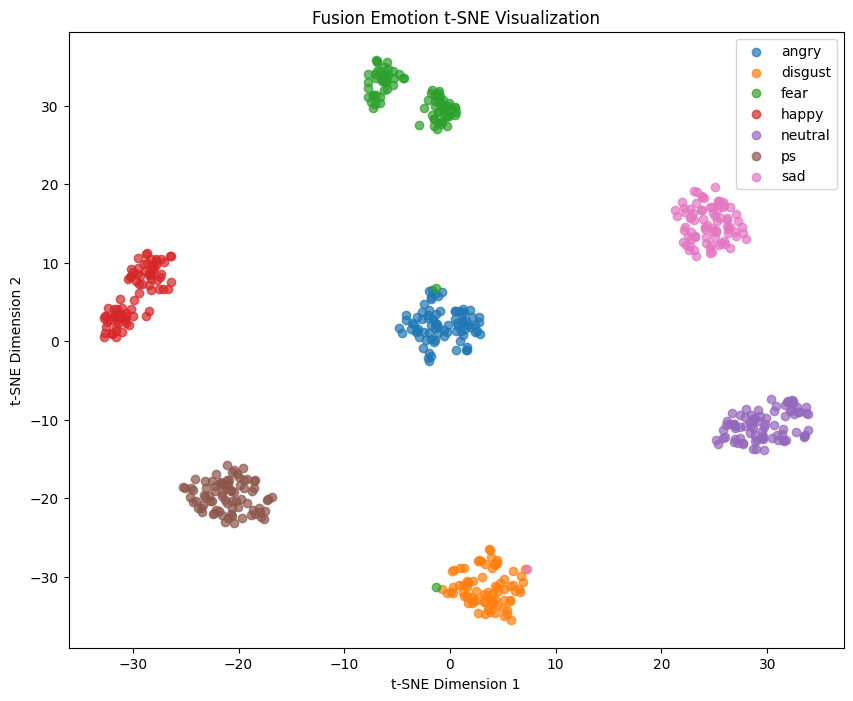

In [17]:
# t-SNE VISUALIZATION


from sklearn.manifold import TSNE
from tensorflow.keras.models import Model



feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-3].output
)

fusion_embeddings = feature_extractor.predict(
    [speech_test, text_test]
)


# APPLY t-SNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

fusion_tsne = tsne.fit_transform(fusion_embeddings)


# VISUALIZATION


plt.figure(figsize=(10,8))

for emotion_index, emotion_name in enumerate(encoder.classes_):

    indices = np.where(y_true == emotion_index)

    plt.scatter(
        fusion_tsne[indices, 0],
        fusion_tsne[indices, 1],
        label=emotion_name,
        alpha=0.7
    )

plt.title("Fusion Emotion t-SNE Visualization")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend()

plt.show()

In [16]:

# SAVE MODEL

model.save(
    "/content/drive/MyDrive/multimodal_emotion_ Recognisation/fusion_emotion_model.keras"
)

print("Fusion model saved successfully.")

Fusion model saved successfully.
